In [ ]:
%load_ext autoreload
%autoreload 2
import sys
import os

sys.path.append(os.path.abspath("../../espaloma-charge_mod/"))
sys.path.append(os.path.abspath('../')) 
import ResParTools as pt
from espaloma_charge import charge
import numpy as np
from rdkit.Chem.Draw import IPythonConsole
import json
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, rdFMCS
from typing import Callable
# import psiresp
import nglview as nv
import MDAnalysis as mda
import glob
import re

import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display, clear_output

IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = (600, 400)

In [2]:
# Лог для отладки: вызовы функций pt, их параметры, сообщения, словари сопоставления
# и промежуточные молекулы пишутся в logs/<дата_время>/ (log.txt, calls.jsonl, files/).
# Выключить: pt.stop_log()
log_dir = pt.start_log()

Лог включён: /home/nikolay/Documents/VS_code/ResParTools/notebooks_and_examples/AF_546_cys/logs/2026-09-29_13-03-36


In [3]:
!pwd

/home/nikolay/Documents/VS_code/ResParTools/notebooks_and_examples/AF_546_cys


# Протокол расчета парциальных зарядов для модифицированных аминокислот
На вход подаються .smi-файлы мономера и полимеров аминокислоты, где аминокислота входит в состав полимера в положениях N M C. 
У мономера должны бать группы COO<sup>-</sup> и N<sup>+</sup>H<sub>3</sub>. У полимеров соответствующие группы на С и N концах.  

In [5]:
PTM_name = 'C_AF546'
base_name = '546'
parent_residue = 'C'  # родительский остаток модификации (цистеин)

## Шаг 1. Открытие мономера и тримера
`pt.file_opener` определяет формат по расширению (`.smiles`, `.pdb`, `.mol2`) и возвращает словарь `{имя файла: молекула RDKit}` с явными водородами.

In [7]:
monomer_chem = pt.file_opener('molecules/C_AF_546.smiles')
trimers_chem = pt.file_opener(['molecules/ACA_AF_546.smiles'])
mon_name = next(iter(monomer_chem))
pol_name = next(iter(trimers_chem))
print(mon_name, pol_name, sep='\n')

Загрузка файла: C_AF_546 (формат: .smiles)


Загрузка файла: ACA_AF_546 (формат: .smiles)
C_AF_546
ACA_AF_546


## Шаг 2. Поиск мономера в тримере
Мономер ищется в тримере; в подструктуру попадают атомы мономера, которые есть и в тримере, то есть атомы остатка в составе цепи (без концевого OH и лишнего H аминогруппы).

In [9]:
match_dict = pt.match_mon_to_pol(monomer_chem, trimers_chem, only_heavy_mapping=True, timeout=5)
sub_chem = match_dict['substructure'][mon_name]
sub_chem_no_H = match_dict['substructure_no_H'][mon_name]
print('атомов в подструктуре:', sub_chem.GetNumAtoms())
print('атомов в подструктуре без водорода:', sub_chem_no_H.GetNumAtoms())


Выполнение Поиск подструктуры между молекулами.  


Выполнение Поиск подструктуры между молекулами.. 


Выполнение Поиск подструктуры между молекулами...


Выполнение Поиск подструктуры между молекулами.  


Выполнение Поиск подструктуры между молекулами.. 

...


Выполнение Поиск подструктуры между молекулами.. 


Выполнение Поиск подструктуры между молекулами...


Выполнение Поиск подструктуры между молекулами.  


Выполнение Поиск подструктуры между молекулами.. 


Поиск подструктуры между молекулами выполнен успешно!
⚠ MCS остановлен по timeout, подструктура может быть неполной
атомов в подструктуре: 122
атомов в подструктуре без водорода: 71


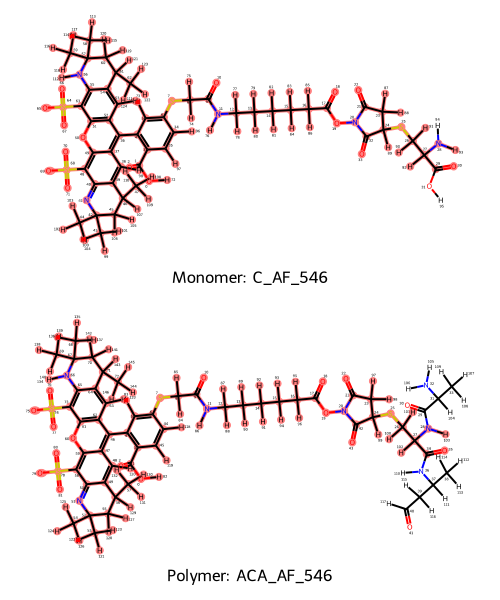

In [10]:
pt.draw_mon_pol_match(monomer_chem, trimers_chem, match_dict, add_small_atom_index=True)

## Шаг 3. Сохранение подструктуры
Подструктура сохраняется как есть: исходная индексация атомов, без имён атомов и остатка (PDB и SMILES).

PDB по умолчанию сохраняется с **2D-координатами** (`coords='2D'`): раскладка однозначна, а RDKit при чтении такого файла не придумывает стереохимию. Раньше здесь строилась случайная 3D-структура, и по ней при чтении получались случайные R/S, из-за чего на шаге 3.1 менялся порядок атомов.

3D-структура строится с `coords='3D'` (то же в `save_aa_chem_to_pdb`):
- `stereo={индекс: 'R'/'S'}` - явно заданные стереоцентры;
- `ca_config='L'` - CA аминокислоты (по умолчанию L, как в белках; L-цистеин по CIP - R, остальные L-аминокислоты - S);
- `stereo_default='R'` - остальные незаданные центры, функция печатает, какие это центры;
- `random_seed=42` - одна и та же молекула даёт одни и те же координаты.

In [12]:
pt.save_chem_to_pdb(sub_chem, f'molecules/substructure/3_{mon_name}')
pt.save_aa_chem_to_smiles(sub_chem, f'molecules/substructure/3_{mon_name}', canonical=False, make_N_root=False, atom_map=True)
pt.save_chem_to_pdb(sub_chem_no_H, f'molecules/substructure/3_{mon_name}_no_H')
pt.save_aa_chem_to_smiles(sub_chem_no_H, f'molecules/substructure/3_{mon_name}_no_H', canonical=False, make_N_root=False, atom_map=True)

3_C_AF_546.smiles saved to molecules/substructure
3_C_AF_546_no_H.smiles saved to molecules/substructure


Загрузка файла: 3_C_AF_546 (формат: .pdb)
атомов в файле: 122 | в подструктуре: 122


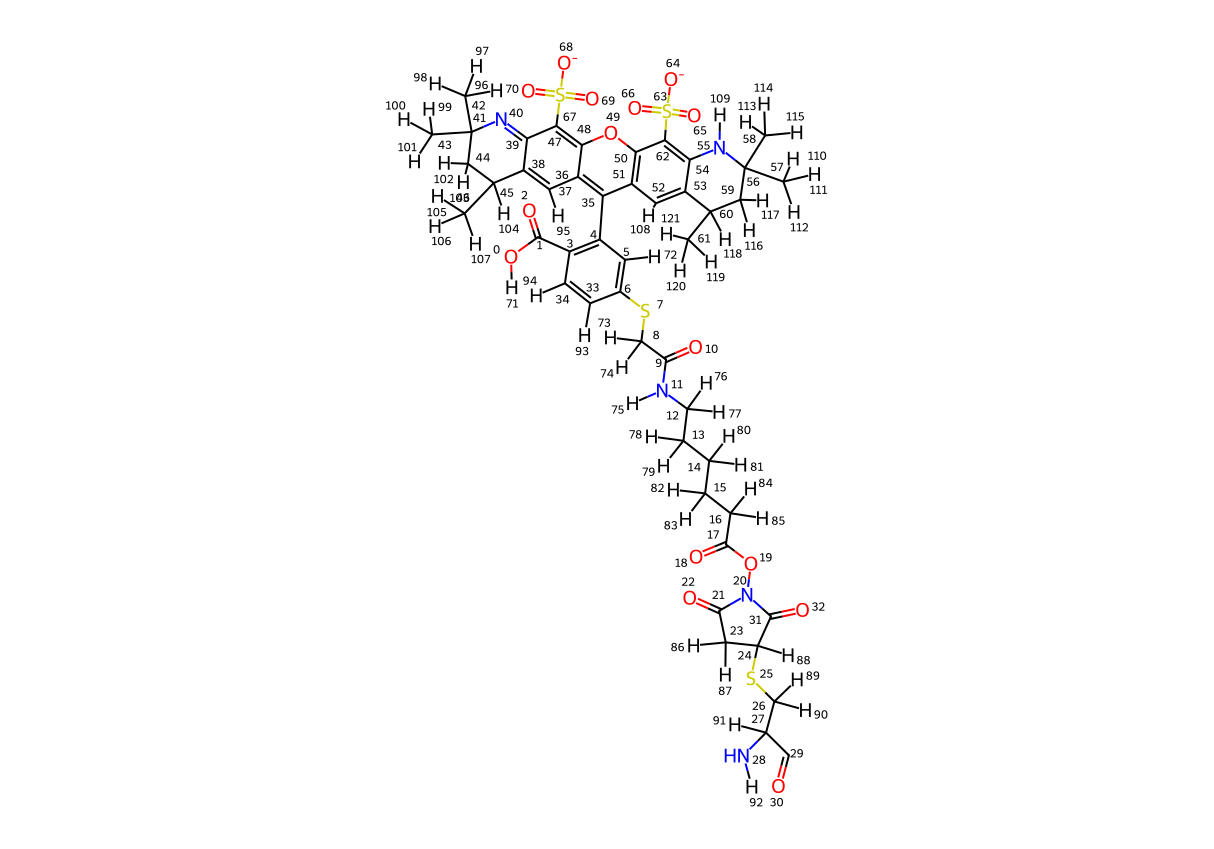

In [13]:
# проверка: файл читается обратно, число атомов совпадает
pdb_chem = pt.file_opener(f'molecules/substructure/3_{mon_name}.pdb')[f'3_{mon_name}']
print('атомов в файле:', pdb_chem.GetNumAtoms(), '| в подструктуре:', sub_chem.GetNumAtoms())
pt.draw_mol_with_atom_index(pdb_chem)

Загрузка файла: 3_C_AF_546 (формат: .smiles)
атомов в файле: 122 | в подструктуре: 122


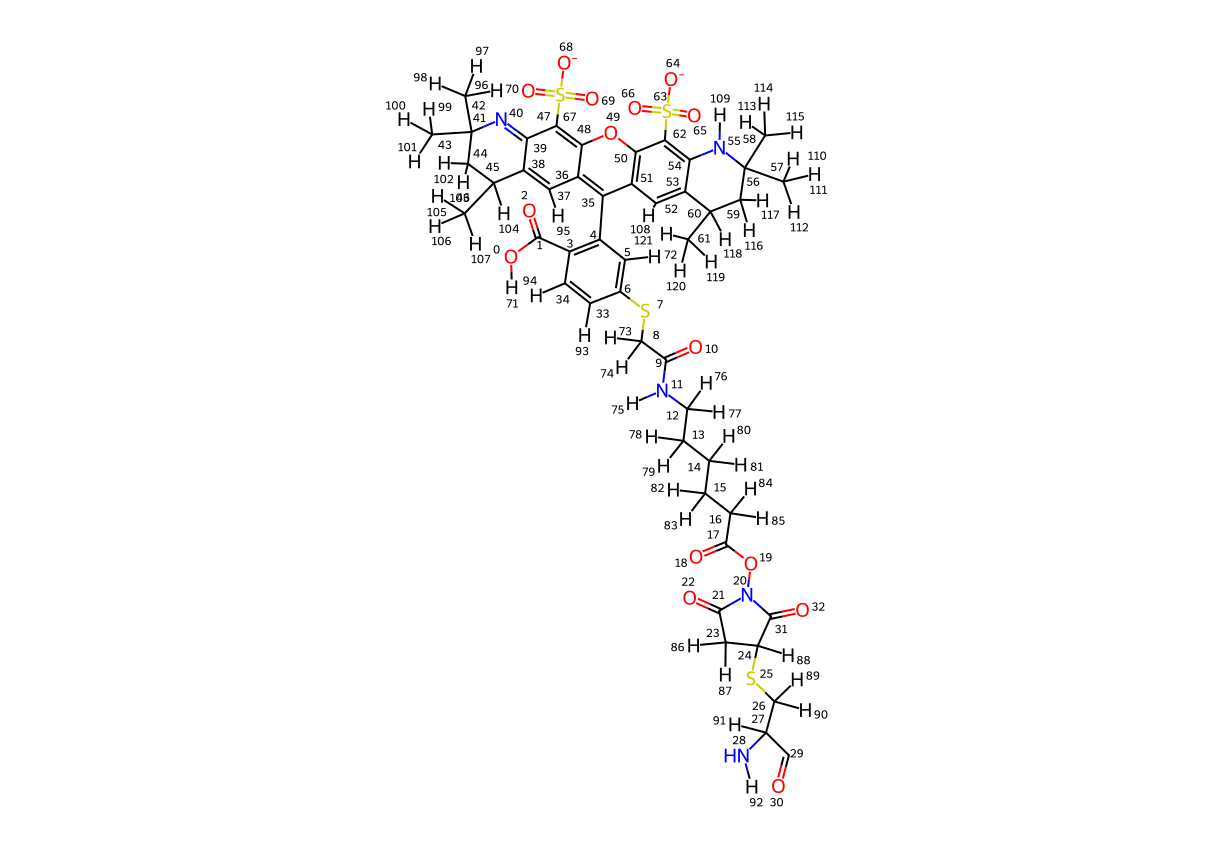

In [14]:
# проверка: файл читается обратно, число атомов совпадает
smiles_chem = pt.file_opener(f'molecules/substructure/3_{mon_name}.smiles')[f'3_{mon_name}'] # потому что словарь
print('атомов в файле:', smiles_chem.GetNumAtoms(), '| в подструктуре:', sub_chem.GetNumAtoms())
pt.draw_mol_with_atom_index(smiles_chem)

## Шаг 3.1. Перенумерация атомов
В подструктуре находится основание - атомы родительского остатка; они получают номера в порядке шаблона (`N H CA HA CB HB1 HB2 SG ... C O`). Остальные атомы нумеруются обходом молекулярного графа: новые атомы встают сразу за каноническим атомом, к которому пришиты, каждый водород - за своим тяжёлым атомом. Порядок не зависит от исходной нумерации и от стереохимии. На картинке подсвечены атомы родительского остатка (`ParentAtoms`).

Результат сохраняется в `3_1_<имя>.pdb`. Это ещё **не остаток**: порядок атомов уже правильный (индекс атома = порядковый номер строки в файле, с 0), но имена атомов - автоматические имена RDKit (элемент + счётчик по элементу: `N3`, `C18`, `H22`), они не совпадают с индексами и нигде дальше не используются; остаток `UNL`, запись `HETATM`. Имена, имя и номер остатка задаются на шаге 3.2.


Выполнение Поиск подструктуры между молекулами.  


Поиск подструктуры между молекулами выполнен успешно!
Родительский остаток: цистеин (Cys, C), шаблон GCG_H; сопоставлено атомов: 10.
Перенумеровано атомов: 122 из 122 (канонических: 10)
атомы родительского остатка: [0, 1, 2, 3, 4, 5, 6, 7, 120, 121]


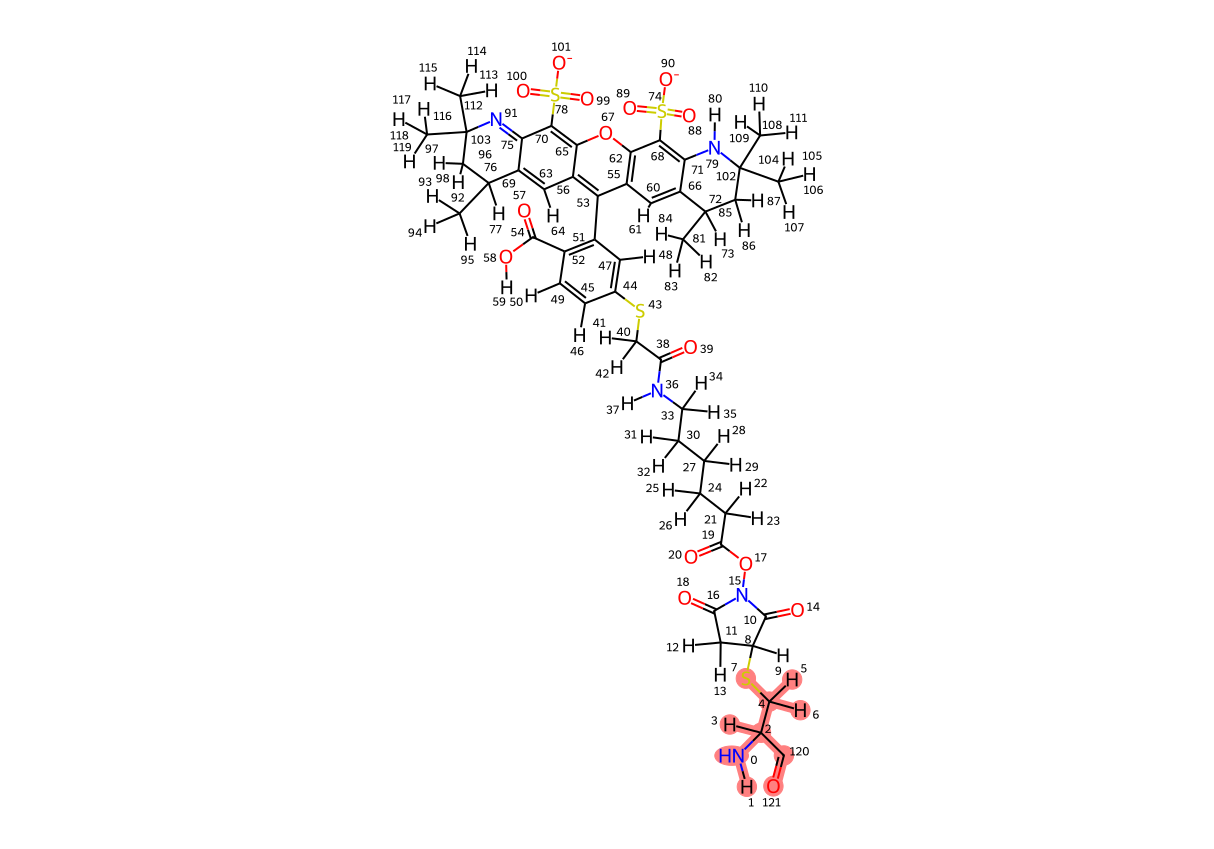

In [16]:
renum_chem = pt.renumber_residue_atoms(pdb_chem, ref_base_name = parent_residue, timeout=5)
# подсвечены атомы, сопоставленные с шаблоном родительского остатка
parent_atoms = json.loads(renum_chem.GetProp('ParentAtoms'))
print('атомы родительского остатка:', parent_atoms)
pt.draw_mol_with_atom_index(renum_chem, highlight_atoms=parent_atoms)

In [17]:
pt.save_chem_to_pdb(renum_chem, f'molecules/substructure/3_1_{mon_name}')

## Шаг 3.2. Имена атомов и сохранение остатка
Атомам присваиваются PDB-имена, задаются имя остатка (не более 3 символов), номер и цепь. Сохраняются версии с водородами и без (`_no_H`). Имена строятся только по графу и индексам атомов, старые имена не используются, а переданная молекула не меняется - повторный запуск ячейки даёт тот же файл. Остов всегда `N CA C O`, водород при N - `H`, при CA - `HA`.

**Способ 1 - буквенный, `naming='greek'` (по умолчанию).** Как в amber14sb. Тяжёлые атомы боковой цепи делятся на уровни по числу связей от CA, уровень задаёт букву: 1 - B, 2 - G, 3 - D, 4 - E, 5 - Z, 6 - H, 7 - T, 8 - I, 9 - K, 10 - L, 11 - M, 12 - N. Номер добавляется, только если на уровне несколько тяжёлых атомов. Водород = `H` + имя своего атома без элемента (+ номер, если водородов несколько).
```
уровень:     0    1     2     3     4     5     6
             CA - CB  - CG  - CD  - CE  - NZ  - CH1   HH11 HH12 HH13
             |    HB1   HG1   HD1   HE1   |
             HA   HB2   HG2   HD2   HE2   + - CH2   HH21 HH22 HH23
                                          |
                                          + - CH3   HH31 HH32 HH33
                                    (Lysine_3M: на уровне 6 три атома -> CH1, CH2, CH3)
```
Подходит для небольших остатков: букв хватает на 12 уровней, имя - не больше 4 символов. Если это не так (у AF546 атомы метки находятся в 27 связях от CA), функция предупреждает и называет атомы способом 2.

**Способ 2 - по индексу, `naming='index'`.** Атомы родительского остатка (`parent_atoms` из шага 3.1) называются буквенным способом, все остальные - элемент + индекс атома из шага 3.1, так что имя сразу показывает номер атома на картинке шага 3.1.
```
индекс:      0 1  2  3   4   5   6    7    8    9     10
             N-H  CA-HA  CB  HB1 HB2  SG - C8 - H9    C10 ...   метка: элемент + индекс
                  |      |            |
                  +------+------------+   родительский остаток (подсвечен на шаге 3.1):
                                          буквенные имена N H CA HA CB HB1 HB2 SG ... C O
```

In [19]:
# проверка: файл читается обратно, число атомов совпадает
renum_chem = pt.file_opener(f'molecules/substructure/3_1_{mon_name}.pdb')[f'3_1_{mon_name}']
print('атомов в файле:', renum_chem.GetNumAtoms(), '| в подструктуре:', sub_chem.GetNumAtoms())

Загрузка файла: 3_1_C_AF_546 (формат: .pdb)
атомов в файле: 122 | в подструктуре: 122


In [20]:
# у метки 27 уровней от CA - буквенный способ неприменим, называем по индексу;
# parent_atoms - атомы цистеина из шага 3.1 (индексы в файле 3_1 те же)
pt.save_aa_chem_to_pdb(renum_chem, f'molecules/substructure/3_2_{mon_name}',
                       resname=base_name, resid=2, segid='A', make_N_root=False,
                       naming='index', parent_atoms=parent_atoms)

Имена атомов (способ 'index'): родительский остаток - N H CA HA CB HB1 HB2 SG C O; остальные 112 атомов - элемент + индекс.
3_2_C_AF_546.pdb saved to molecules/substructure
3_2_C_AF_546_no_H.pdb saved to molecules/substructure


In [21]:
# ОТКЛЮЧЕНО: эта строка перезаписывала 3_2_<имя>.pdb файлом без имён атомов (шаг 3.2).
# pt.save_chem_to_pdb(sub_chem, f'molecules/substructure/3_2_{mon_name}')
# pt.save_aa_chem_to_smiles(sub_chem, f'molecules/substructure/{mon_name}', canonical=False, make_N_root=False, atom_map=True)
# pt.save_chem_to_pdb(sub_chem_no_H, f'molecules/substructure/3_{mon_name}_no_H')
# pt.save_aa_chem_to_smiles(sub_chem_no_H, f'molecules/substructure/{mon_name}_no_H', canonical=False, make_N_root=False, atom_map=True)

In [22]:
nv.show_mdanalysis(mda.Universe(f'molecules/substructure/3_2_{mon_name}.pdb'))

NGLWidget()

## Шаг 4. Проверка остатка
Имена атомам уже присвоены на шаге 3.2 (раньше это делал шаг 4: имена канонических атомов переносились из референсного остатка через `find_ref_aa`). Здесь остаток проверяется, при необходимости меняются имена атомов и параметры остатка, проверяются дубликаты имён, и сохраняются итоговый PDB и `general_atoms.json` - имена атомов родительского остатка (их читает `3_edd_topology.ipynb`, чтобы взять типы атомов и заряды остова из amber14sb).

Загрузка файла: 3_2_C_AF_546 (формат: .pdb)


атомов: 122 | остаток (имя, номер, цепь): {('546', 2, 'A')}


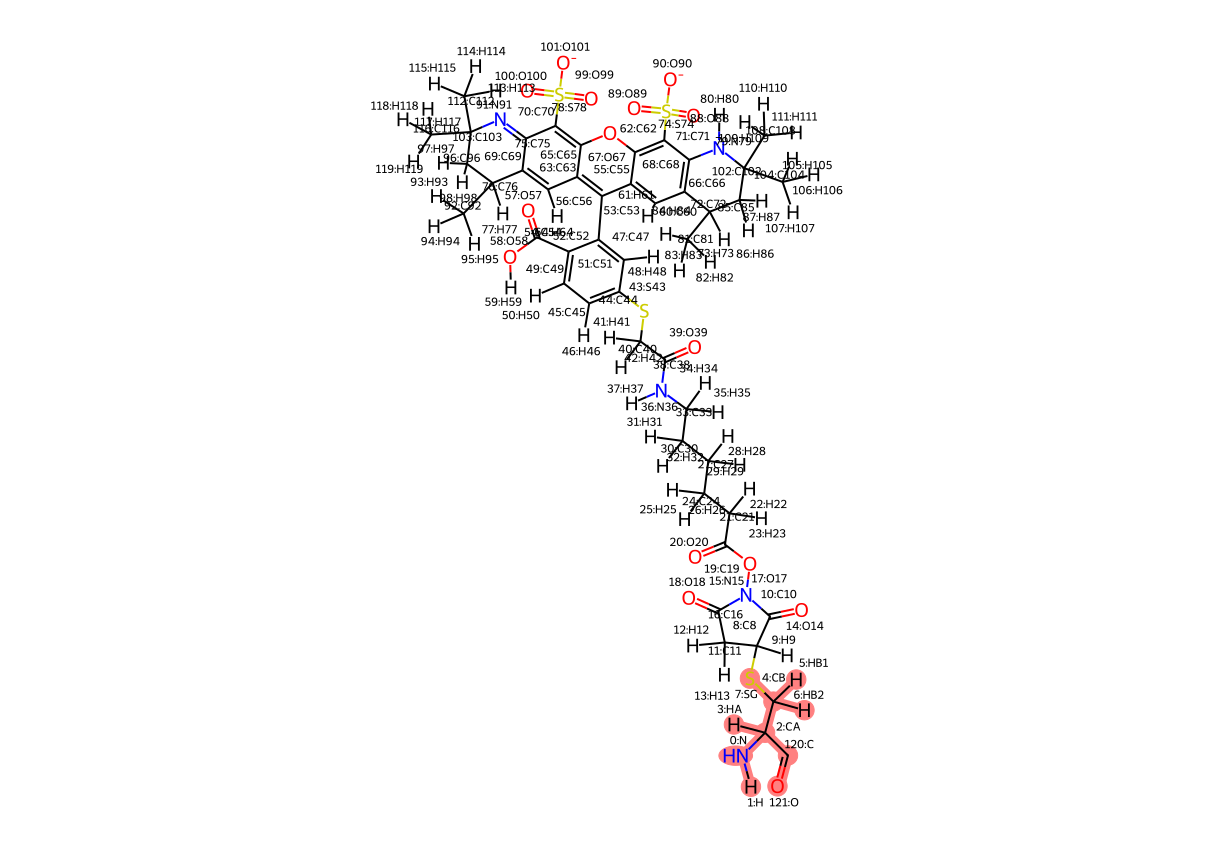

In [24]:
# остаток из шага 3.2: имена атомов, имя и номер остатка, цепь
residue_chem = pt.file_opener(f'molecules/substructure/3_2_{mon_name}.pdb')[f'3_2_{mon_name}']
res_params = {(a.GetPDBResidueInfo().GetResidueName(), a.GetPDBResidueInfo().GetResidueNumber(),
               a.GetPDBResidueInfo().GetChainId()) for a in residue_chem.GetAtoms()}
print('атомов:', residue_chem.GetNumAtoms(), '| остаток (имя, номер, цепь):', res_params)
# подписи «индекс:имя», подсвечен родительский остаток
pt.draw_mol_with_atom_index(residue_chem, highlight_atoms=parent_atoms, show_names=True)

### Изменение имён атомов и параметров остатка (при необходимости)
`rename_map = {'старое имя': 'новое имя'}`; если новое имя уже занято другим атомом, тот атом получает следующее свободное имя (`CB` → `CB1`). Пустой словарь - имена не меняются, задаются только имя, номер и цепь остатка.

In [26]:
rename_map = {}
residue_chem = pt.modifie_residue_info(residue_chem, rename_map, resname=base_name, resid=2, segid='A')

### Проверка имён атомов на дубликаты

In [28]:
duplicates = pt.check_duplicate_atom_names(residue_chem)
if duplicates:
    raise ValueError(f'Повторяющиеся имена атомов (имя: индексы): {duplicates}')

Дубликаты имен атомов не найдены.


### Сохранение результата шага 4

In [30]:
pt.save_chem_to_pdb(residue_chem, f'molecules/substructure/4_{mon_name}')
# имена атомов родительского остатка - для 3_edd_topology.ipynb
general_atoms = [residue_chem.GetAtomWithIdx(i).GetProp('AtomName') for i in parent_atoms]
print('general_atoms:', general_atoms)
pt.save_json('general_atoms', general_atoms)
modifie_residue = residue_chem  # вход шага 4.1

general_atoms: ['N', 'H', 'CA', 'HA', 'CB', 'HB1', 'HB2', 'SG', 'C', 'O']
Файл успешно сохранен: 
/home/nikolay/Documents/VS_code/ResParTools/notebooks_and_examples/AF_546_cys/general_atoms.json


In [31]:
# Все функции этой ячейки есть в ResParTools.py (pt.check_duplicate_atom_names, pt.modifie_residue_info,
# pt.save_molecule_as_pdb, ...), поэтому копии закомментированы. Вызывать через pt.
# from collections import Counter

# from rdkit import Chem
# from rdkit.Chem import AllChem

# def check_PDB_residue_info(atom):
#     """
#     Проверяет, что параметры остатка были правильно установлены для атома.
#     """
#     monomer_info = atom.GetMonomerInfo()
    # assert monomer_info.IsValid(), "Информация об остатке не установлена!"
#     assert monomer_info.GetName().strip(), "Имя атома не установлено!"
#     assert monomer_info.GetResidueName().strip(), "Имя остатка не установлено!"
#     assert monomer_info.GetResidueNumber() >= 1, "Номер остатка не установлен!"
#     assert monomer_info.GetChainId().strip(), "ID сегмента не установлен!"
#     print(f"Параметры остатка для атома {monomer_info.GetName()} установлены корректно.", 
#           monomer_info.GetName(), 
#           monomer_info.GetResidueName(),
#         monomer_info.GetResidueNumber(),
#         monomer_info.GetChainId(),sep='\n')

# def check_duplicate_atom_names(mol):
#     """
#     Проверяет наличие атомов с одинаковыми именами в молекуле и возвращает словарь.
#     """
    # Получаем список всех имен атомов
#     atom_names = [atom.GetProp('AtomName') for atom in mol.GetAtoms()]

    # Подсчитываем частоту появления каждого имени
#     name_count = Counter(atom_names)
#     print(name_count)
    # Формируем словарь с именами атомов и их индексами в молекуле
#     atom_indices = {}
#     for i, atom in enumerate(mol.GetAtoms()):
#         name = atom.GetProp('AtomName')
#         if name in atom_indices:
#             atom_indices[name].append(i)
#         else:
#             atom_indices[name] = [i]

    # Отбираем только те атомы, которые имеют одинаковые имена
#     duplicates = {name: indices for name, indices in atom_indices.items() if len(indices) > 1}

#     if duplicates:
#         print("Обнаружены атомы с одинаковыми именами:")
#         for name, indices in duplicates.items():
#             print(f"Имя: '{name}', Индексы атомов: {indices}")
#     else:
#         print("Дубликаты имен атомов не найдены.")

#     return duplicates

# def set_PDB_residue_info(atom, atom_name, resname='MOD', resid=1, segid='A'):
    
#     info = Chem.AtomPDBResidueInfo()
#     info.SetName(atom_name.ljust(4))        # Имя должно быть ровно 4 символа
#     info.SetResidueName(resname)            # Устанавливаем имя остатка
#     info.SetResidueNumber(resid)            # Устанавливаем номер остатка
#     info.SetChainId(segid)                  # Устанавливаем ID сегмента
#     atom.SetMonomerInfo(info)
    # return info
    

# def modifie_residue_info(modified_mol,  index_map, resname='MOD', resid=1, segid='A'):
#     """
#     Назначает новые имена атомам в молекуле согласно индексному отображению.
#     """
    # ref_mol_atom_dict = {atom.GetIdx(): atom.GetProp('AtomName') for atom in reference_mol.GetAtoms() if atom.GetPDBResidueInfo().GetResidueNumber()==2 }
    
#     for atom in modified_mol.GetAtoms():
#         atom_name = atom.GetProp('AtomName') 
        
#         if atom_name in index_map.keys():
#             atom_name = index_map[atom_name]
#             atom.SetProp("AtomName", atom_name)
#             print(f'Имя атома {atom.GetSymbol()} с индексом {atom.GetIdx()} заменено на имя {atom_name} ')
#             set_PDB_residue_info(atom, atom_name, resname, resid, segid) 
#         else:
#             ref_names = set(index_map.values()) 
#             new_name = atom_name
#             if atom_name in ref_names:
#                 while new_name in ref_names:
#                     new_name = increment_name(new_name)
#                 print(f'Имя атома {atom_name} с индексом {atom.GetIdx()} заменено на имя {new_name} ')
#             set_PDB_residue_info(atom, atom_name, resname, resid, segid)
#     return modified_mol

# def increment_name(name):
#     match = re.match(r'(\D+)(?:(\d*))$', name)
#     if match:
#         base, num_str = match.groups()
#         num = int(num_str or '0')
#         return f'{base}{num + 1}'
#     else:
#         return f'{name}1' # это странно, типа для случая CH1A 

# def write_modified_molecule(mol, output_path):
#     """
#     Записывает измененную молекулу в PDB-файл.
#     """
#     writer = Chem.PDBWriter(output_path)
#     for atom in mol.GetAtoms():
#         atom.SetMonomerType(atom.GetProp('AtomName'))
#     writer.write(mol)
#     writer.close()
    
# def save_molecule_as_pdb(molecule, filename, format_coord='3D'):
#     """
#     Сохраняет молекулу в формате PDB.

#     :param molecule: Молекула в формате RDKit Mol.
#     :param filename: Имя файла для сохранения.
#     :param format: Формат представления ('2D' или '3D'). По умолчанию '3D'.
#     """
#     if format_coord == '2D':
        # Рассчитываем 2D координаты
#         AllChem.Compute2DCoords(molecule)
#     elif format_coord == '3D':
        # Рассчитываем 3D координаты (если еще не рассчитаны)
#         Chem.SanitizeMol(molecule)
#         AllChem.EmbedMolecule(molecule)
#         AllChem.UFFOptimizeMolecule(molecule)
#     else:
#         raise ValueError("Недопустимый формат. Выберите '2D' или '3D'.")
    
#     path_to_file, file_name = pt.path_parser(filename, ['pdb'])
#     save_path = f'{path_to_file}/{file_name}_{format_coord}.pdb'
    # Сохраняем молекулу в PDB формате
#     with open(save_path, 'w') as pdb_file:
#         pdb_file.write(Chem.MolToPDBBlock(molecule))
#     print(f"Молекула успешно сохранена в файле {save_path} в формате {format_coord}.")

# def add_names_from_residue(modified_chem, index_map, resname='MOD', resid=1, segid='A'):
    # Загружаем молекулы

    
#     mod_mol = list(modified_chem.values())[0] # костыль работы с словарем молекулы
    # ref_mol = list(reference_chem.values())[0] # костыль работы с словарем молекулы
   

#     key_map = next(iter(match_data_dict['mon_pol_matches'].keys()))
#     index_map = match_data_dict['mon_pol_matches'][key_map]
    # Присваиваем новые имена атомам в модифицированной молекуле
    # Перезадаем параметры модифицированного остатка  
#     mod_residue = modifie_residue_info(mod_mol, index_map, resname, resid, segid)
    
    # Проверка наличия дублирующих имен атомов
#     has_duplicates = check_duplicate_atom_names(mod_residue)
    # print(has_duplicates)
    
#     return mod_residue

### Шаг 4.1. Протонирование атомов, потерявших стандартную валентность 

Этот шаг необходим для дальнейшего получения файла itp для нашей а.к. \
Дело в том, что acpype отказывается создавать топологию для атомов с нестандартными валентностями, что вполне логично. Поэтому мы добавляем протоны, которых на самом деле нет в остатке. После в процесе редактирвоания itp мы удалим все строки с лишними протонами. \
Стоит отметить, что этот шаг можно также выполнить с использованием любого удобного вам молекулярного редактора (ChimeraX, PyMOL) взяв за основу pdb фаийл сохраненный на 3-ем шаге.

In [ ]:
# add_protons_and_renumber_H есть в ResParTools.py - копия закомментирована, вызов через pt.
# Создание карты индексов атомов и их номеров

# def add_protons_and_renumber_H(modifie_residue, resname='MOD', resid=1, segid='A'):
#     atom_map = {atom.GetIdx(): atom.GetProp('AtomName') for atom in modifie_residue.GetAtoms()}
#     names = list(atom_map.values())
    # print(atom_map)

    # Добавление протонов
#     H_modifie_residue = Chem.AddHs(modifie_residue, addCoords=True)
#     AllChem.Compute2DCoords(H_modifie_residue)
    
    # Назначение уникальных имен для новых атомам водорода
#     for atom in H_modifie_residue.GetAtoms():
#         if atom.GetPDBResidueInfo() is None:
#             info = atom.GetPDBResidueInfo()
#             print(info, atom.GetIdx(), atom.GetAtomMapNum())
            
#             new_name = 'HW1'
#             while new_name in names:
#                 new_name = increment_name(new_name)
#             names.append(new_name)

#             set_PDB_residue_info(atom, new_name, resname, resid, segid)
#             atom.SetProp('AtomName', new_name)
#             atom.SetAtomMapNum(atom.GetIdx())
            # atom.SetI() = int(atom.GetAtomMapNum())
        
#     order = [atom.GetIdx() for atom in H_modifie_residue.GetAtoms()]
#     Chem.rdmolops.RenumberAtoms(H_modifie_residue, order)
    
#     return H_modifie_residue

In [34]:
H_modifie_residue = pt.add_protons_and_renumber_H(modifie_residue, resname = base_name, resid=2, segid='A')

None 25 0
None 26 0


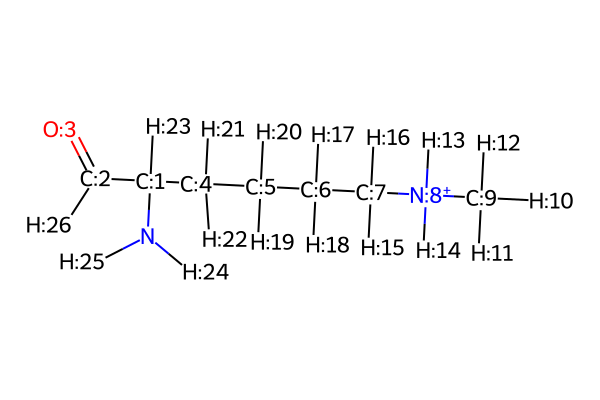

In [35]:
pt.draw_mol_with_atom_index(H_modifie_residue)

In [36]:
for atom in H_modifie_residue.GetAtoms():
    info = atom.GetPDBResidueInfo()
    print(info.GetResidueNumber(), info.GetResidueName(), atom.GetProp('AtomName'), atom.GetIdx(), atom.GetAtomMapNum())

2 K1M N 0 0
2 K1M CA 1 1
2 K1M C 2 2
2 K1M O 3 3
2 K1M CB 4 4
2 K1M CG 5 5
2 K1M CD 6 6
2 K1M CE 7 7
2 K1M NZ 8 8
2 K1M CH 9 9
2 K1M HH3 10 10
2 K1M HH2 11 11
2 K1M HH1 12 12
2 K1M HZ2 13 13
2 K1M HZ1 14 14
2 K1M HE2 15 15
2 K1M HE1 16 16
2 K1M HD2 17 17
2 K1M HD1 18 18
2 K1M HG2 19 19
2 K1M HG1 20 20
2 K1M HB2 21 21
2 K1M HB1 22 22
2 K1M HA 23 23
2 K1M H 24 24
2 K1M HW1 25 25
2 K1M HW2 26 26


In [37]:

save_molecule_as_pdb(H_modifie_residue, f'molecules/substructure/{PTM_name}_rn_H.pdb', format_coord='3D')

Молекула успешно сохранена в файле molecules/substructure/Lysine_1M_rn_H_3D.pdb в формате 3D.


In [38]:
pt.save_aa_chem_to_smiles(H_modifie_residue, f'molecules/substructure/{chem_name}_rn_H.smiles', canonical=False ,make_N_root=False)

Lysine_1M_rn_Hles.smiles saved to molecules/substructure


In [37]:
test = mda.Universe(f'{PTM_name}/molecules/substructure/{PTM_name}_rn_H_3D.pdb')
nv.show_mdanalysis(test)

NGLWidget()

#### Дополнителоьные шаги отладки

In [60]:
chek_mol = mda.Universe('molecules/substructure/Lysin_2M_RENAME.pdb')

all_mod_atom_names = chek_mol.atoms.names
name_counts = Counter(all_mod_atom_names)  # Подсчитываем частоту каждого имени
duplicates = [name for name, count in name_counts.items() if count > 1]  # Список дубликатов

if duplicates:
    print("В модифицированной молекуле обнаружены повторяющиеся имена атомов:")
    for name in duplicates:
        print(f"Имя: {name}, количество повторений: {name_counts[name]}")
    raise ValueError("Обнаружены повторяющиеся имена атомов. Проверьте логи для деталей.")
else:
    print("Все имена атомов уникальны.")

Все имена атомов уникальны.


/home/n_kristovsky/.conda/envs/topmol2/lib/python3.8/site-packages/MDAnalysis/coordinates/PDB.py:432: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn("1 A^3 CRYST1 record,"


In [97]:
nv.show_mdanalysis(mda.Universe('molecules/substructure/Lysin_1M_RENAME.pdb'))

NGLWidget()

In [99]:
pt.draw_mol_with_atom_index(mod_aa_chem_dict['Lysin_3M'])

KeyError: 'Lysin_3M'

In [48]:
mod_aa_chem_dict['Lysin_3M'].GetNumAtoms()

33

In [207]:
test_pdb_dict = pt.pdb_to_chem('molecules/substructure/TestNR_CIT_mod.pdb')
ref_aa = pt.pdb_to_chem('molecules/aminoacids_template/RRR.pdb')
print(test_pdb_dict, ref_aa)

{'RRR': <rdkit.Chem.rdchem.Mol at 0x7fbfb9a03640>}

In [196]:
substructure, dict_mol1_mol2_matches = pt.match_chem(ref_aa['RRR'], test_pdb_dict['TestNR_CIT_mod'])

In [205]:
substructure.GetNumAtoms()

23

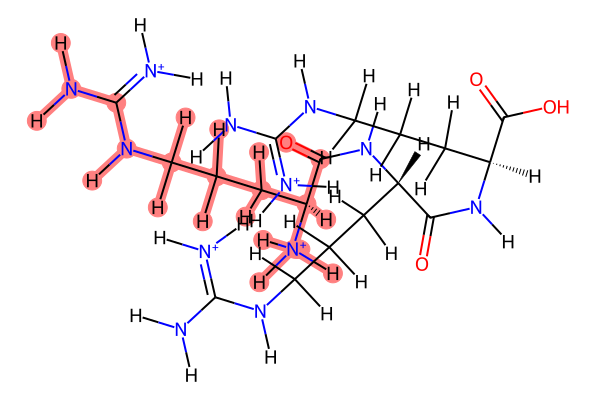

In [197]:
ref_aa['RRR']

In [25]:
# NR = mda.Universe('molecules/aminoacids_template/NR.pdb')
NRCIT = mda.Universe('molecules/substructure/TestNR_CIT_mod.pdb')
NRCIT.residues.resnums

/home/n_kristovsky/.conda/envs/topmol2/lib/python3.8/site-packages/psiresp/charge.py:282: FutureWarning: `symmetric_atoms_are_equivalent` will be set to False by default for now, as it is a new feature. It will be set to True by default in the future
  warnings.warn(


array([2])

In [184]:
for ref_indx, mod_indx in dict_mol1_mol2_matches.items():
    print( NR.atoms.names[ref_indx] + ':' + NRCIT.atoms.names[mod_indx])

N:N1
CA:C1
CB:C2
CG:C3
CD:C4
NE:N2
CZ:C5
NH1:N3
HH11:H1
HH12:H2
HE:H3
HD2:H4
HD3:H5
HG2:H6
HG3:H7
HB2:H8
HB3:H9
C:C6
O:O2
HA:H10
H1:H11
H2:H12
H3:H13


/home/n_kristovsky/.conda/envs/topmol2/lib//python3.8/site-packages/MDAnalysis/coordinates/PDB.py:432: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn("1 A^3 CRYST1 record,"


In [193]:
for ref_indx, mod_indx in dict_mol1_mol2_matches.items():
    NRCIT.atoms[mod_indx].name = NR.atoms[ref_indx].name 
print(NRCIT.atoms.names)

['N' 'CA' 'CB' 'CG' 'CD' 'NE' 'CZ' 'NH1' 'HH11' 'HH12' 'O1' 'HE' 'HD2'
 'HD3' 'HG2' 'HG3' 'HB2' 'HB3' 'C' 'O' 'HA' 'H1' 'H2' 'H3']


In [190]:
# NRCIT.atoms.names[1] = 'AD'
NRCIT.atoms.

'C1'

In [191]:
print(dict_mon_pol_matches)

{0: 0, 1: 1, 4: 2, 5: 3, 6: 4, 7: 5, 8: 6, 9: 7, 19: 8, 20: 9, 18: 11, 16: 12, 17: 13, 14: 14, 15: 15, 12: 16, 13: 17, 2: 18, 3: 19, 11: 20, 23: 21, 24: 22, 25: 23}


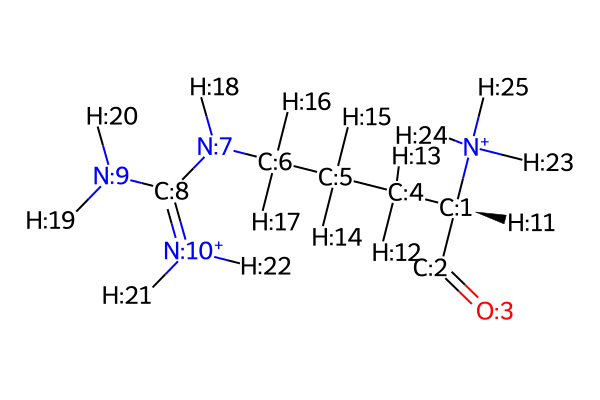

In [177]:
pt.draw_mol_with_atom_index(ref_aa['NR'])

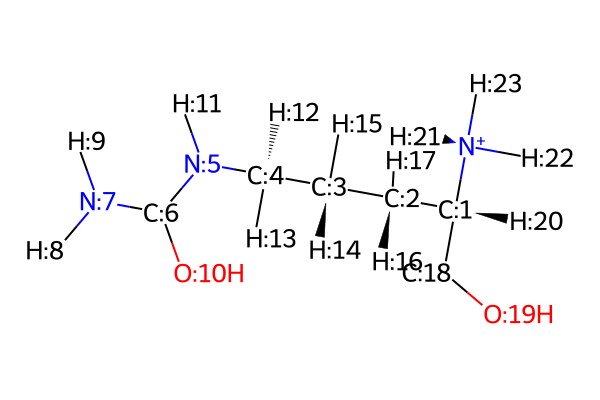

In [169]:
pt.draw_mol_with_atom_index(test_pdb_dict['TestNR_CIT_mod'])

In [151]:
mda_sub.residues.resids

array([1])

In [ ]:
list_N = []
for sub in match_dict['substructure'].values():
    N_index = pt.find_amino_nitrogen(sub)
    list_N.append(N_index)
print(list_N)
sub_name = ['NR_CIT', 'R_CIT', 'CR_CIT']
for chem_name, chem_mol, root in zip(sub_name, match_dict['substructure'].values(), list_N):
    pt.save_chem_to_pdb(chem_mol, f'molecules/substructure/{chem_name}', rootedAtAtom = root)
    print(chem_name, chem_mol)

## Шаг 5. Расчет зарядов при помощи библиотеки Espaloma Charge

На вход: 
- Молекула-ы в виде тримеров в формате smiles. 

Задача ограничейни зарядов для одной молекулы


Создание ограничений

In [6]:
!pwd

/home/_shared/_projects/2022_md_FRET_nv/AI_param_tool/notebooks/Lysine_1M


In [7]:
PTM_name

'Lysine_1M'

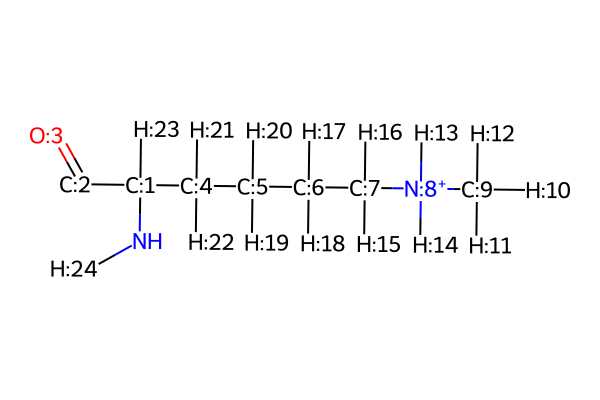

In [8]:
residue = pt.pdb_to_chem(f'molecules/substructure/{mon_name}.pdb')
pt.draw_mol_with_atom_index(residue[mon_name])

In [9]:
constraint_dict = {f'{mon_name}':
                  {'symmetric_list': [],
                   'charge_atom_dict': {0:-0.34790, 24:0.27470, 
                                        1:-0.24000, 2:0.73410, 
                                        3:-0.58940, 23:0.14260},
                   'charge_of_monomer': 1.0000,
                  }
                  }

### Расчет зарядов при помощи библиотеки Espaloma Charge

In [10]:
charges = charge(residue[mon_name], 
                 constraints=constraint_dict[mon_name]['charge_atom_dict']
                )

print(f'Суммарный заряд молекулы: {sum(charges)}', charges, sep = '\n')


/home/n_kristovsky/.conda/envs/espaloma/lib/python3.9/site-packages/dgl/heterograph.py:92: DGLWarning: Recommend creating graphs by `dgl.graph(data)` instead of `dgl.DGLGraph(data)`.
  dgl_warning(


Суммарный заряд молекулы: 1.0
[-0.3479     -0.24        0.7341     -0.5894     -0.1970251  -0.22330597
 -0.19959679 -0.02957197 -0.6957726  -0.07841596  0.19370374  0.19370374
  0.19370374  0.29249054  0.29249054  0.19166155  0.19166155  0.16812657
  0.16812657  0.14138722  0.14138716  0.1405727   0.1405727   0.1426
  0.2747    ]


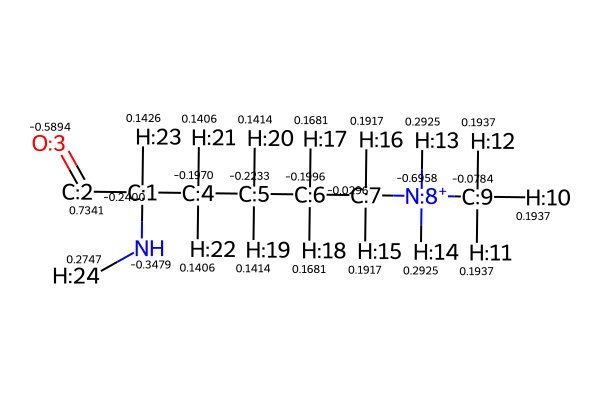

In [11]:
pt.draw_mol_with_atom_index(residue[mon_name], charge_list=charges)

## Сохранение масcива зарядов

In [12]:
pt.save_charges_json(name = f'AI_chrges_{mon_name}', charge_list = charges.tolist(),  )

Файл успешно сохранен: 
/home/_shared/_projects/2022_md_FRET_nv/AI_param_tool/notebooks/Lysine_1M/AI_chrges_Lysine_1M.json
